# Bert Model

In [13]:
import sys
import os
import matplotlib.pyplot as plt
from pathlib import Path
from src.model.predict_model import predict_sentiment_bert

reviews = [
        "this movie was great and the acting was amazing",
        "this movie was mid"]

for review in reviews:
    print("BERT Prediction:", predict_sentiment_bert(review))
    print("BERT Prediction with best params:", predict_sentiment_bert(review, with_params=True))

BERT Prediction: positive (confidence: 99.93%)
BERT Prediction with best params: positive (confidence: 99.87%)
BERT Prediction: negative (confidence: 99.47%)
BERT Prediction with best params: negative (confidence: 59.60%)


=== SEPARATE MODEL ANALYSIS ===
Processing 13 checkpoints for BERT Base Model...
✓ Plotted 822 data points for BERT Base Model
Processing 10 checkpoints for BERT Optimized (with params)...
✓ Plotted 364 data points for BERT Optimized (with params)


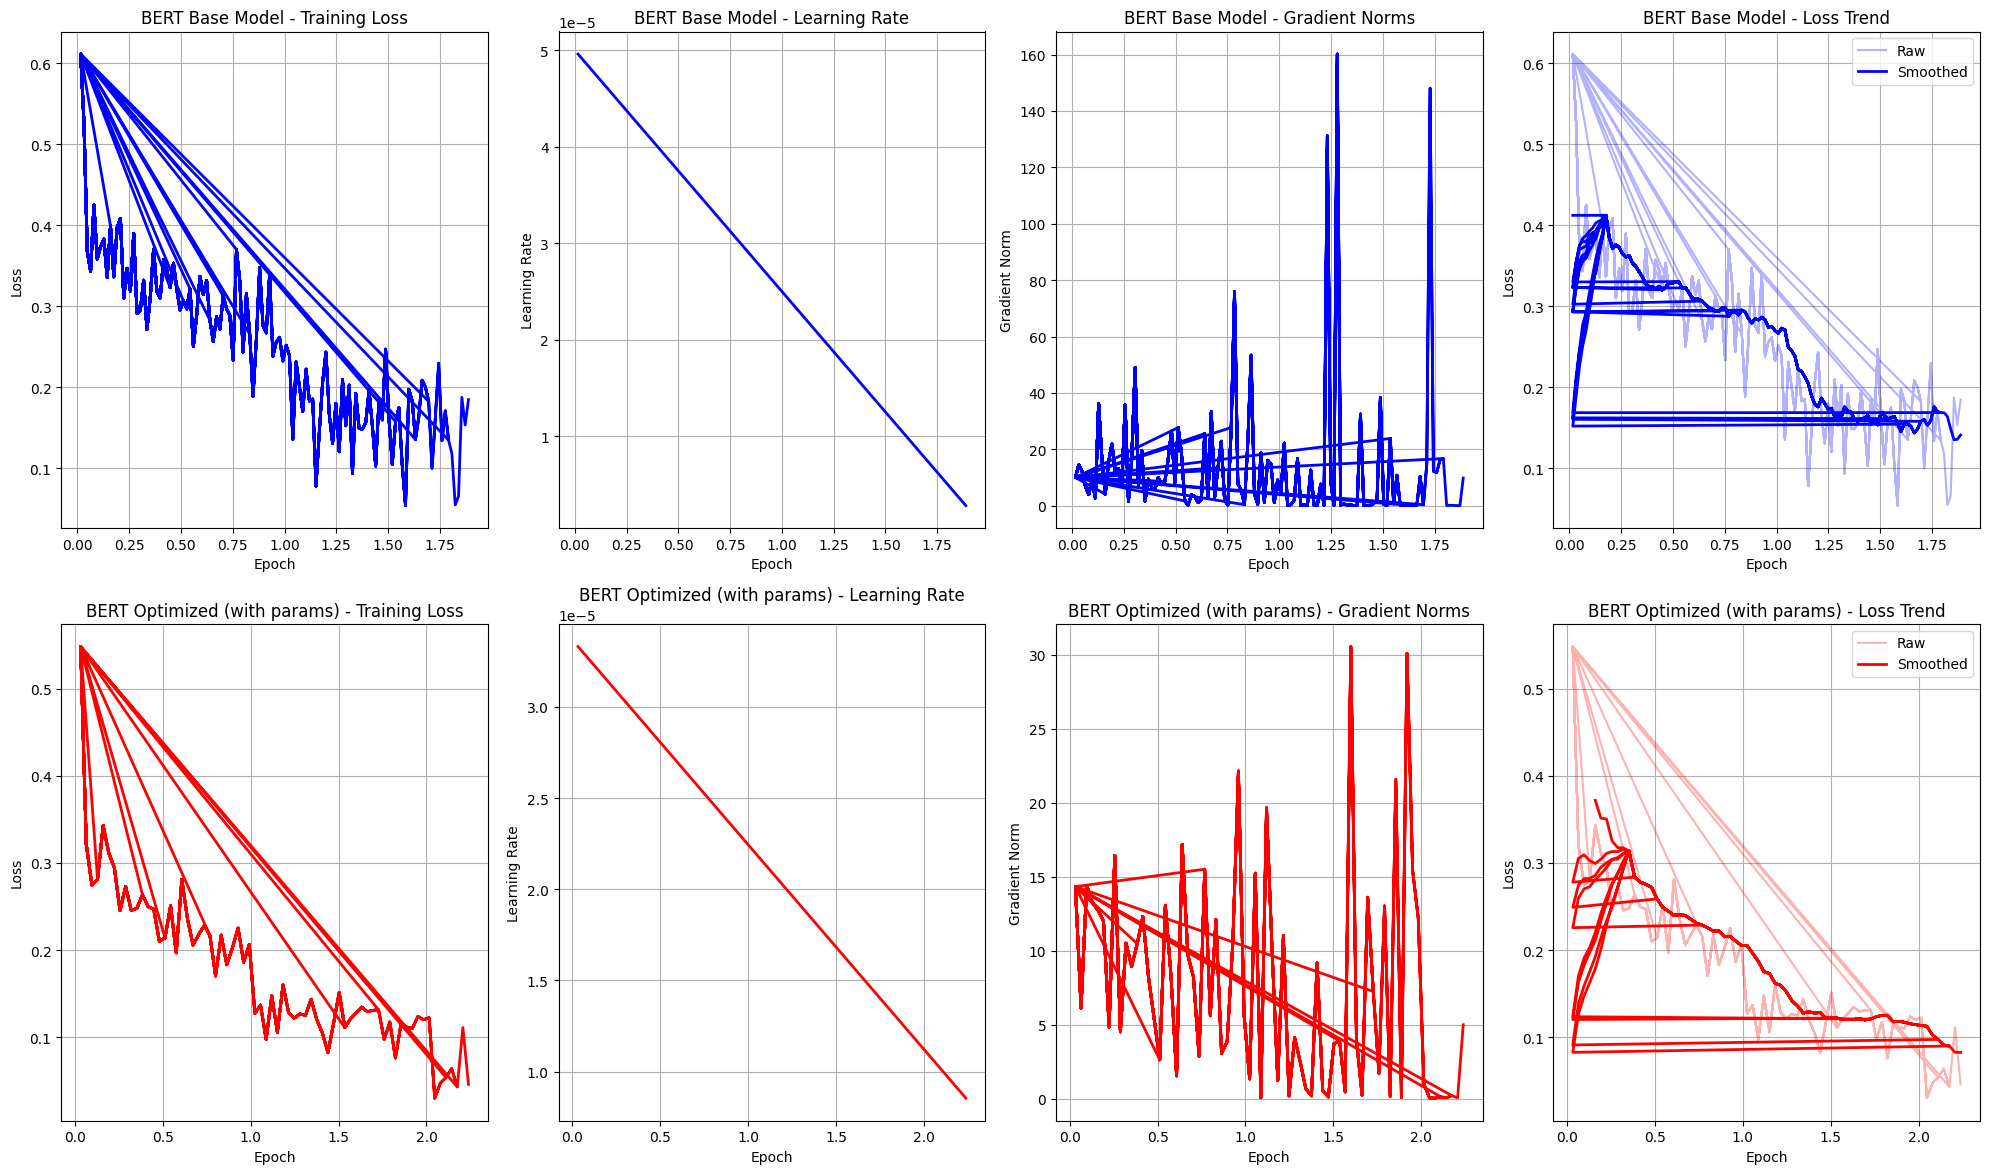


=== DIRECT COMPARISON ===


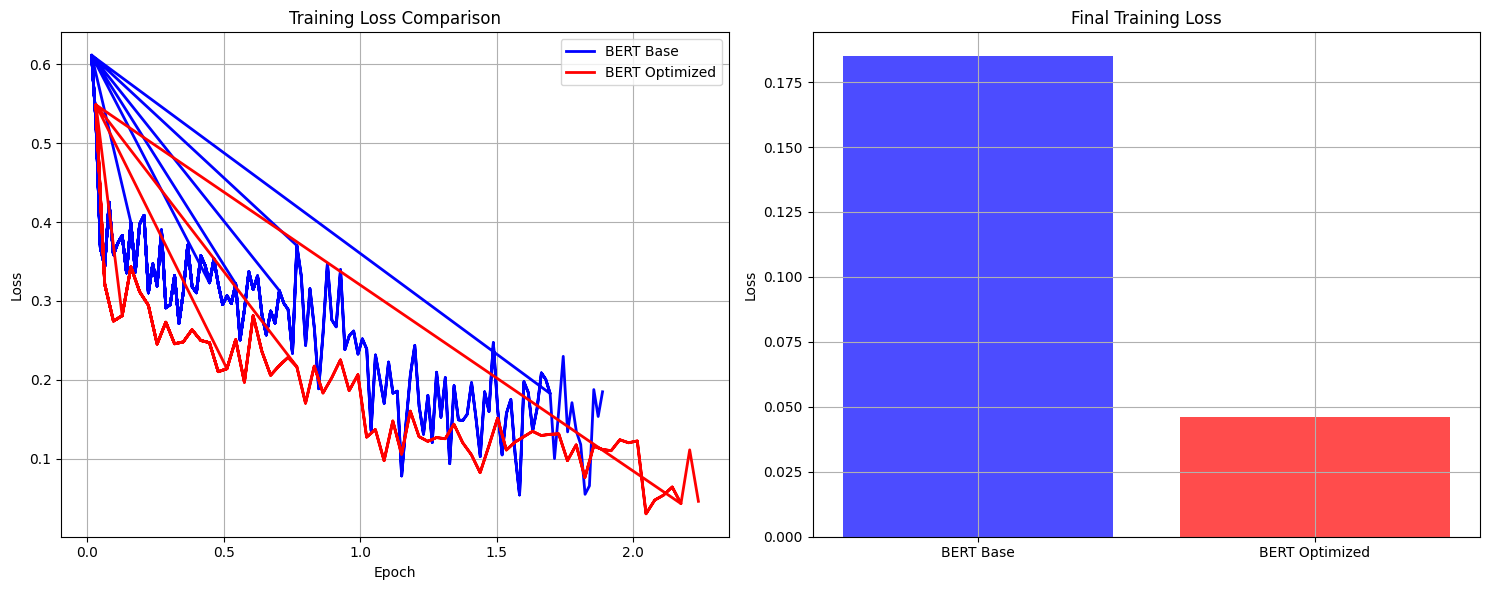

In [10]:
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path

def plot_model_comparison():    
    models = {
        "BERT Base Model": Path("models/bert_model"),
        "BERT Optimized (with params)": Path("models/bert_model_with_params")
    }
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 12))
    colors = ['blue', 'red']
    
    for model_idx, (model_name, model_dir) in enumerate(models.items()):
        if not model_dir.exists():
            print(f"Model directory {model_dir} doesn't exist")
            continue
            
        checkpoints = list(model_dir.glob("checkpoint-*"))
        if not checkpoints:
            print(f"No checkpoints found in {model_dir}")
            continue
            
        sampled_checkpoints = checkpoints[::5] # every 5th checkpoint
        
        epochs = []
        train_losses = []
        learning_rates = []
        grad_norms = []
        
        print(f"Processing {len(sampled_checkpoints)} checkpoints for {model_name}...")
        
        for checkpoint_dir in sorted(sampled_checkpoints, key=lambda x: int(x.name.split('-')[1])):
            trainer_state_path = checkpoint_dir / "trainer_state.json"
            if trainer_state_path.exists():
                with open(trainer_state_path, 'r') as f:
                    state = json.load(f)
                
                for log_entry in state.get('log_history', []):
                    if 'epoch' in log_entry:
                        epochs.append(log_entry['epoch'])
                    if 'loss' in log_entry:
                        train_losses.append(log_entry['loss'])
                    if 'learning_rate' in log_entry:
                        learning_rates.append(log_entry['learning_rate'])
                    if 'grad_norm' in log_entry:
                        grad_norms.append(log_entry['grad_norm'])
        
        if not epochs:
            print(f"No training data found for {model_name}")
            continue
            
        color = colors[model_idx]
        
        if train_losses:
            axes[model_idx, 0].plot(epochs, train_losses, color=color, linewidth=2)
            axes[model_idx, 0].set_title(f'{model_name} - Training Loss')
            axes[model_idx, 0].set_xlabel('Epoch')
            axes[model_idx, 0].set_ylabel('Loss')
            axes[model_idx, 0].grid(True)
        
        if learning_rates:
            axes[model_idx, 1].plot(epochs, learning_rates, color=color, linewidth=2)
            axes[model_idx, 1].set_title(f'{model_name} - Learning Rate')
            axes[model_idx, 1].set_xlabel('Epoch')
            axes[model_idx, 1].set_ylabel('Learning Rate')
            axes[model_idx, 1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
            axes[model_idx, 1].grid(True)
        
        if grad_norms:
            axes[model_idx, 2].plot(epochs, grad_norms, color=color, linewidth=2)
            axes[model_idx, 2].set_title(f'{model_name} - Gradient Norms')
            axes[model_idx, 2].set_xlabel('Epoch')
            axes[model_idx, 2].set_ylabel('Gradient Norm')
            axes[model_idx, 2].grid(True)
        
        if len(train_losses) > 10:
            window_size = min(10, len(train_losses) // 5)
            smoothed_loss = []
            smoothed_epochs = []
            
            for i in range(window_size, len(train_losses)):
                smoothed_loss.append(sum(train_losses[i-window_size:i]) / window_size)
                smoothed_epochs.append(epochs[i])
            
            axes[model_idx, 3].plot(epochs, train_losses, alpha=0.3, color=color, label='Raw')
            axes[model_idx, 3].plot(smoothed_epochs, smoothed_loss, color=color, linewidth=2, label='Smoothed')
            axes[model_idx, 3].set_title(f'{model_name} - Loss Trend')
            axes[model_idx, 3].set_xlabel('Epoch')
            axes[model_idx, 3].set_ylabel('Loss')
            axes[model_idx, 3].legend()
            axes[model_idx, 3].grid(True)
        
        print(f"✓ Plotted {len(epochs)} data points for {model_name}")
    
    plt.tight_layout()
    plt.show()

def plot_direct_comparison():    
    models = {
        "BERT Base": Path("models/bert_model"),
        "BERT Optimized": Path("models/bert_model_with_params")
    }
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    colors = ['blue', 'red']
    
    for model_idx, (model_name, model_dir) in enumerate(models.items()):
        if model_dir.exists():
            checkpoints = list(model_dir.glob("checkpoint-*"))
            sampled_checkpoints = checkpoints[::10]
            
            epochs = []
            train_losses = []
            
            for checkpoint_dir in sorted(sampled_checkpoints, key=lambda x: int(x.name.split('-')[1])):
                trainer_state_path = checkpoint_dir / "trainer_state.json"
                if trainer_state_path.exists():
                    with open(trainer_state_path, 'r') as f:
                        state = json.load(f)
                    
                    for log_entry in state.get('log_history', []):
                        if 'epoch' in log_entry and 'loss' in log_entry:
                            epochs.append(log_entry['epoch'])
                            train_losses.append(log_entry['loss'])
            
            if train_losses:
                ax1.plot(epochs, train_losses, color=colors[model_idx], 
                        linewidth=2, label=model_name)
                
                final_loss = train_losses[-1] if train_losses else 0
                ax2.bar(model_name, final_loss, color=colors[model_idx], alpha=0.7)
    
    ax1.set_title('Training Loss Comparison')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.set_title('Final Training Loss')
    ax2.set_ylabel('Loss')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

print("=== SEPARATE MODEL ANALYSIS ===")
plot_model_comparison()

print("\n=== DIRECT COMPARISON ===")
plot_direct_comparison()